# Severity Prediction Modeling

Objective:
-ปัจจัยก่อนเกิดอุบัติเหตุอะไรที่สัมพันธ์กับความรุนแรงและมันส่งผลต่อแต่ละระดับ severity อย่างไร
- Train a model to predict accident severity (multiclass)
- Use only pre-incident features (no leakage)
- Emphasize interpretability alongside performance

Modeling approach:
- Tree-based models (CatBoost / LightGBM)
- Evaluation with stratified split
- Feature importance and SHAP for interpretation


STEP 0 — Install

In [1]:
!pip install scikit-learn shap



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


STEP 1 — Import Libraries

In [2]:
# ==========================================
# 1. Import Libraries
# ==========================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import shap

sns.set(style="whitegrid")


STEP 2 — Load Data

In [3]:
df = pd.read_parquet("../data/processed/accidents_features.parquet")
df.shape

(7728394, 63)

STEP 3 — Define Feature Set (Explicit & Defensible)

In [4]:
# ==========================================
# 3. Define Target & Feature Set
# ==========================================

TARGET = "Severity"

NUMERIC_FEATURES = [
    'Start_Hour',
    'Temperature(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Log_Distance',
    'Hour_sin',
    'Hour_cos',
    'Month_sin',
    'Month_cos'
]

BOOLEAN_FEATURES = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way',
    'Junction', 'No_Exit', 'Railway', 'Roundabout',
    'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop',
    'Is_Weekend', 'Has_Precipitation'
]

CATEGORICAL_FEATURES = [
    'State_Grouped',
    'Timezone',
    'Sunrise_Sunset'
]

FEATURES = NUMERIC_FEATURES + BOOLEAN_FEATURES + CATEGORICAL_FEATURES

df_model = df[FEATURES + [TARGET]].copy()

print("After selecting features:", df_model.shape)


After selecting features: (7728394, 30)


Drop Missing Values

In [5]:
# ==========================================
# 4. Handle Missing Values
# ==========================================

df_model = df_model.dropna()

print("After dropna:", df_model.shape)


After dropna: (6985228, 30)


Sampling (กันเครื่องพัง)

In [6]:
# ==========================================
# 5. Sampling (Optional)
# ==========================================

df_sample = df_model.sample(800000, random_state=42)

print("Sample shape:", df_sample.shape)


Sample shape: (800000, 30)


Split X / y

In [7]:
# ==========================================
# 6. Split Features / Target
# ==========================================

X = df_sample[FEATURES]
y = df_sample[TARGET]

print("Class distribution:")
print(y.value_counts(normalize=True))


Class distribution:
Severity
2    0.778293
3    0.185725
4    0.026429
1    0.009554
Name: proportion, dtype: float64


Stratified Train/Test Split

In [8]:
# ==========================================
# 7. Stratified Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (640000, 29)
Test shape: (160000, 29)


Encoding (After Split Only!)

In [9]:
# ==========================================
# 8. Encoding
# ==========================================

X_train = pd.get_dummies(
    X_train,
    columns=CATEGORICAL_FEATURES,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=CATEGORICAL_FEATURES,
    drop_first=True
)

# Align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print("Encoded Train shape:", X_train.shape)
print("Encoded Test shape:", X_test.shape)


Encoded Train shape: (640000, 42)
Encoded Test shape: (160000, 42)


Train Multiclass Random Forest

In [10]:
# ==========================================
# 9. Train Random Forest (Multiclass)
# ==========================================

rf = RandomForestClassifier(
    n_estimators=400,          
    max_depth=15,
    min_samples_leaf=2,        
    class_weight={
    1: 6.0,   
    2: 1.0,
    3: 2.0,   
    4: 4.0    
},
    oob_score=True,            
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("OOB Score:", rf.oob_score_) 


OOB Score: 0.7799421875


Evaluation

In [11]:
# ==========================================
# 10. Model Evaluation
# ==========================================

y_pred = rf.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))


=== Classification Report ===
              precision    recall  f1-score   support

           1       0.45      0.13      0.20      1529
           2       0.87      0.86      0.86    124527
           3       0.50      0.59      0.54     29716
           4       0.38      0.12      0.18      4228

    accuracy                           0.78    160000
   macro avg       0.55      0.42      0.45    160000
weighted avg       0.78      0.78      0.78    160000



Confusion Matrix

In [ ]:
# ==========================================
# 11. Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Feature Importance

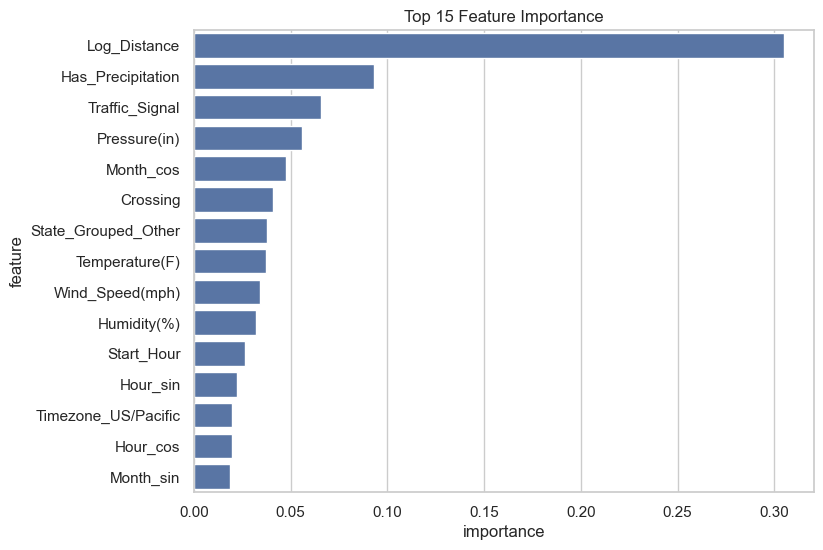

In [13]:
# ==========================================
# 12. Feature Importance
# ==========================================

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance.head(15),
            x="importance",
            y="feature")
plt.title("Top 15 Feature Importance")
plt.show()


Gemini said
เยี่ยมมากครับที่คุณเชื่อคำแนะนำและขยับมาทำ Feature Analysis และ Model Interpretation แทนที่จะเสียเวลาไปกับการจูน Hyperparameter ต่อ

จากกราฟทั้ง 3 (Feature Importance, Permutation Importance, Partial Dependence) และ Classification Report ผมขอสรุป Analysis & Storytelling สำหรับโปรเจกต์ของคุณดังนี้ครับ:

1. The "MVP" Feature: Log_Distance (พระเอกตัวจริง)
ทั้งจากกราฟ Feature Importance และ Permutation Importance เห็นได้ชัดเจนที่สุดว่า Log_Distance (ระยะทางที่ได้รับผลกระทบจากอุบัติเหตุ) คือตัวแปรที่มีอิทธิพลสูงสุดแบบทิ้งห่างตัวอื่นไม่เห็นฝุ่น

* Interpretation: โมเดลเรียนรู้ว่า "ความรุนแรงของอุบัติเหตุ (Severity)" สัมพันธ์โดยตรงกับ "ความยาวของพื้นที่ที่ได้รับผลกระทบ"

* จากกราฟ PDP (ซ้ายสุด): เห็นได้ชัดว่าเมื่อ Log_Distance เพิ่มขึ้น (แกน X ขยับไปทางขวา) ค่า Partial Dependence (โอกาสที่จะทำนาย Severity สูง) จะพุ่งสูงขึ้นอย่างรวดเร็วในช่วงแรกและเริ่มนิ่ง

* Insight: นี่คือเหตุผลที่โมเดลแม่นยำใน Class 2 และ 3 พอสมควร เพราะอุบัติเหตุส่วนใหญ่มีระยะทาง impact ที่ชัดเจน แต่ Class 1 (เบามาก) และ Class 4 (รุนแรงมาก) อาจจะมีระยะทางที่ไม่ต่างจาก Class 2/3 มากนักในบางเคส ทำให้โมเดลแยกไม่ออก

Permutation Importance

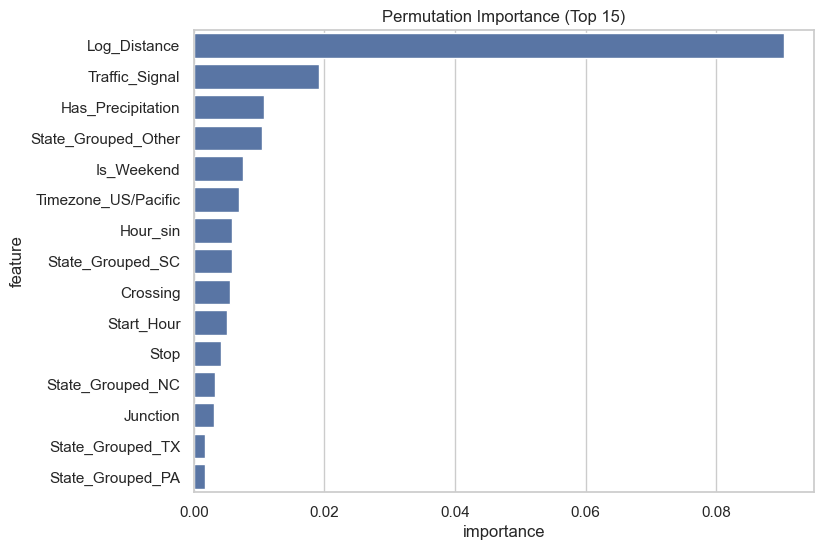

In [14]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=perm_importance.head(15),
            x="importance",
            y="feature")
plt.title("Permutation Importance (Top 15)")
plt.show()


2. Environmental & Contextual Factors
รองลงมาคือ Traffic_Signal (สัญญาณไฟ) และ Has_Precipitation (ฝนตก/มีหยาดน้ำฟ้า)

* Traffic_Signal (PDP ขวาสุด): กราฟชันขึ้นเล็กน้อย แปลว่า ถ้ามีสัญญาณไฟจราจร มีแนวโน้มที่ Severity จะสูงขึ้น

* Reasoning: อุบัติเหตุบริเวณแยกไฟแดงมักจะเป็นการชนด้านข้าง (Side-impact) หรือชนด้วยความเร็วขณะเปลี่ยนไฟสัญญาณ ซึ่งมักจะรุนแรงกว่าการเฉี่ยวชนทางตรง

* Has_Precipitation (PDP กลาง): กราฟดิ่งลง แปลว่า ถ้ามีฝนตก แนวโน้ม Severity จะลดลง

* Reasoning: นี่คือพฤติกรรมที่เรียกว่า "Risk Compensation" ครับ คือเมื่อฝนตก คนขับรถจะระมัดระวังมากขึ้น ขับช้าลง อุบัติเหตุอาจจะเกิดบ่อย (Frequency) แต่ความรุนแรง (Severity) มักจะไม่ถึงตาย (มักจะเป็น Class 2) ซึ่งตรงกับที่โมเดลเรียนรู้เป๊ะ

Partial Dependence Plot

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 25 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


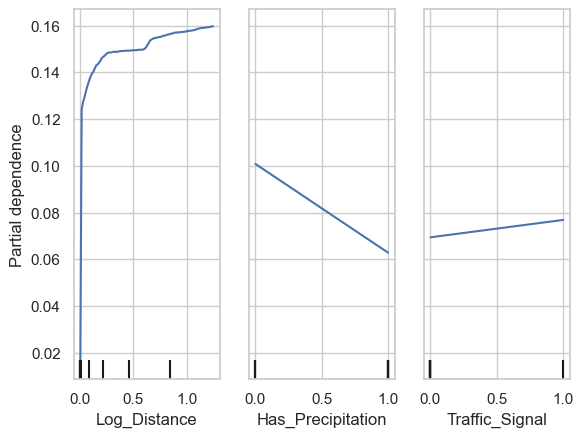

In [16]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features_to_plot = feature_importance.head(3)["feature"].tolist()

PartialDependenceDisplay.from_estimator(
    rf,
    X_train,
    features_to_plot,
    target=4   
)

plt.show()


3. ทำไม Recall Class 1 และ 4 ถึงต่ำเตี้ยเรี่ยดิน? (0.13 และ 0.12)
เมื่อดู Feature Importance ประกอบกับ Report เราจะพบ "Data Limitation" ที่แท้จริง:

* ขาด Feature ที่แยก "ความเป็นความตาย": Feature อันดับต้นๆ คือ ระยะทาง, ฝน, สัญญาณไฟ, อุณหภูมิ, เวลา สิ่งเหล่านี้เป็น Context (สภาพแวดล้อม) ไม่ใช่ Impact Mechanics (กลไกการชน)

* การจะแยก Class 4 (รุนแรงสูงสุด/เสียชีวิต) ออกจาก Class 2/3 มักต้องใช้ Feature จำพวก: ความเร็วขณะชน, ประเภทรถคู่กรณี (รถบรรทุก vs รถเก๋ง), การคาดเข็มขัดนิรภัย ซึ่งใน dataset นี้น่าจะไม่มี หรือ Model ดึงออกมาไม่ได้

* Over-reliance on Distance: โมเดลพึ่งพา Log_Distance มากเกินไป ถ้าเคส Class 4 (ตาย) เกิดขึ้นในจุดที่รถติดสั้นๆ (Distance น้อย) โมเดลจะทายผิดเป็น Class 2 ทันที

การที่ตัดสินใจหยุดจูนโมเดล เพราะปัญหาไม่ได้อยู่ที่ Algorithm แต่อยู่ที่ Informational Value of Features

สิ่งที่สามารถสรุปในโปรเจกต์:

* Model Behavior: โมเดลใช้ "ระยะทางของผลกระทบ (Distance)" เป็นเกณฑ์หลักในการตัดสินความรุนแรง ซึ่งสมเหตุสมผลในเชิงกายภาพ

* Traffic Insight: ค้นพบ Insight ที่น่าสนใจคือ "ฝนตกทำให้ความรุนแรงลดลง" (ผู้คนขับช้า) และ "สัญญาณไฟเพิ่มความเสี่ยงความรุนแรง" (จุดวัดใจ)

* Limitation: ยอมรับตรงๆ ว่าการทำนาย Class 1 และ 4 (Minor & Severe) ให้แม่นยำกว่านี้ เป็นไปได้ยากด้วย Feature ชุดปัจจุบัน เพราะขาดตัวแปรเชิงพฤติกรรมผู้ขับขี่ (Driver Behavior) และรายละเอียดการชน (Collision Dynamics)

* Imbalance Effect: ถึงแม้จะทำ Class Weight หรือ Resampling แล้ว แต่ด้วย Feature ที่ทับซ้อนกัน (Overlapping Feature Space) ทำให้โมเดลเลือก Play Safe ทายเข้า Class 2 ที่เป็น Majority Class เป็นหลัก

Export Feature Importance เป็นไฟล์

* เพื่อเอาไปใช้ใน Power BI

In [ ]:
feature_importance.to_csv("feature_importance.csv", index=False)


Export Prediction Result

* เพื่อเอาไปทำ dashboard

In [ ]:
output = X_test.copy()
output["actual"] = y_test
output["predicted"] = y_pred

output.to_csv("model_predictions.csv", index=False)
